In [1]:
from pathlib import Path
from langchain_google_genai import ChatGoogleGenerativeAI

from pydantic import BaseModel, Field
from chromadb import PersistentClient
from tqdm import tqdm
from litellm import completion
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go

import config, os

os.environ['GEMINI_API_KEY'] = config.GEMINI_API_KEY

MODEL = "gemini/gemini-2.5-flash"

DB_NAME = "preprocessed_db"
collection_name = "docs"
embedding_model = "gemini-embedding-001"
KNOWLEDGE_BASE_PATH = Path("knowledge-base")
AVERAGE_CHUNK_SIZE = 500


chat = ChatGoogleGenerativeAI(
    model=MODEL,
    temperature=0,  # Gemini 3.0+ defaults to 1.0
    max_output_tokens=500,
    thinking_budget=0,
    timeout=None,
    max_retries=2,
    seed=121
)

C:\Users\Rohan\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Inspired by LangChain's Document - let's have something similar

class Result(BaseModel):
    page_content: str
    metadata: dict

In [3]:
# A class to perfectly represent a chunk

class Chunk(BaseModel):
    headline: str = Field(description="A brief heading for this chunk, typically a few words, that is most likely to be surfaced in a query")
    summary: str = Field(description="A few sentences summarizing the content of this chunk to answer common questions")
    original_text: str = Field(description="The original text of this chunk from the provided document, exactly as is, not changed in any way")

    def as_result(self, document):
        metadata = {"source": document["source"], "type": document["type"]}
        return Result(page_content=self.headline + "\n\n" + self.summary + "\n\n" + self.original_text,metadata=metadata)


class Chunks(BaseModel):
    chunks: list[Chunk]

## Document fetching and storing in ChromaDB

In [4]:
# Step1: Fetch documents from the knowledge base, like LangChain did
def fetch_documents():
    """A homemade version of the LangChain DirectoryLoader"""

    documents = []

    for folder in KNOWLEDGE_BASE_PATH.iterdir():
        doc_type = folder.name
        for file in folder.rglob("*.md"):
            with open(file, "r", encoding="utf-8") as f:
                documents.append({"type": doc_type, "source": file.as_posix(), "text": f.read()})

    print(f"Loaded {len(documents)} documents")
    return documents

In [5]:
documents = fetch_documents()

Loaded 76 documents


In [6]:
# Step2: Making of the chunks. Use a LLM for this

def make_prompt(document):
    how_many = (len(document["text"]) // AVERAGE_CHUNK_SIZE) + 1
    return f"""
You take a document and you split the document into overlapping chunks for a KnowledgeBase.

The document is from the shared drive of a company called Insurellm.
The document is of type: {document["type"]}
The document has been retrieved from: {document["source"]}

A chatbot will use these chunks to answer questions about the company.
You should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.
This document should probably be split into {how_many} chunks, but you can have more or less as appropriate.
There should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.

For each chunk, you should provide a headline, a summary, and the original text of the chunk.
Together your chunks should represent the entire document with overlap.

Here is the document:

{document["text"]}

Respond with the chunks.
"""

In [7]:
print(make_prompt(documents[0]))


You take a document and you split the document into overlapping chunks for a KnowledgeBase.

The document is from the shared drive of a company called Insurellm.
The document is of type: company
The document has been retrieved from: knowledge-base/company/about.md

A chatbot will use these chunks to answer questions about the company.
You should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.
This document should probably be split into 5 chunks, but you can have more or less as appropriate.
There should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.

For each chunk, you should provide a headline, a summary, and the original text of the chunk.
Together your chunks should represent the entire document with overlap.

Here is the document:

# About Insurellm

Insurellm was founded by Avery La

In [8]:
def make_messages(document):
    return [
        {"role": "user", "content": make_prompt(document)},
    ]

In [9]:
make_messages(documents[0])

[{'role': 'user',
  'content': "\nYou take a document and you split the document into overlapping chunks for a KnowledgeBase.\n\nThe document is from the shared drive of a company called Insurellm.\nThe document is of type: company\nThe document has been retrieved from: knowledge-base/company/about.md\n\nA chatbot will use these chunks to answer questions about the company.\nYou should divide up the document as you see fit, being sure that the entire document is returned in the chunks - don't leave anything out.\nThis document should probably be split into 5 chunks, but you can have more or less as appropriate.\nThere should be overlap between the chunks as appropriate; typically about 25% overlap or about 50 words, so you have the same text in multiple chunks for best retrieval results.\n\nFor each chunk, you should provide a headline, a summary, and the original text of the chunk.\nTogether your chunks should represent the entire document with overlap.\n\nHere is the document:\n\n# A

In [10]:
def process_document(document):
    messages = make_messages(document)
    response = completion(model=MODEL, messages=messages, response_format=Chunks)
    reply = response.choices[0].message.content
    doc_as_chunks = Chunks.model_validate_json(reply).chunks
    return [chunk.as_result(document) for chunk in doc_as_chunks]

In [11]:
process_document(documents[0])

[Result(page_content='Insurellm Founding and Early Growth\n\nInsurellm was founded in 2015 by Avery Lancaster as an insurance tech startup, launching Markellm as its first product. The company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm, Homellm, and Rellm, and growing to 200 employees with 12 offices by 2020. This period of rapid expansion was followed by a strategic restructuring starting in 2022 to focus on profitability and sustainable growth.\n\n# About InsurellmInsurellm was founded by Avery Lancaster in 2015 as an insurance tech startup designed to disrupt an industry in need of innovative products. Its first product was Markellm, the marketplace connecting consumers with insurance providers.The company experienced rapid growth in its first five years, expanding its product portfolio to include Carllm (auto insurance portal), Homellm (home insurance portal), and Rellm (enterprise reinsurance platform). By 2020, Insurellm ha

In [12]:
def create_chunks(documents):
    chunks = []
    for doc in tqdm(documents):
        chunks.extend(process_document(doc))
    return chunks

In [16]:
chunks = create_chunks(documents)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 76/76 [31:32<00:00, 24.90s/it]


In [17]:
print(len(chunks))

646


In [13]:
from google import genai
client = genai.Client()

In [14]:
result = client.models.embed_content(
        model=embedding_model,
        contents= "hello i am a robot"
    )
result

EmbedContentResponse(
  embeddings=[
    ContentEmbedding(
      values=[
        -0.026280532,
        0.019133514,
        -0.0081132315,
        -0.056473166,
        -0.001471176,
        <... 3067 more items ...>,
      ]
    ),
  ],
  sdk_http_response=HttpResponse(
    headers=<dict len=11>
  )
)

In [24]:
# Step3: saving the chunks 

def create_embeddings(chunks):
    chroma = PersistentClient(path=DB_NAME)
    
    # Reset collection if it exists
    if collection_name in [c.name for c in chroma.list_collections()]:
        chroma.delete_collection(collection_name)
    
    collection = chroma.get_or_create_collection(collection_name)

    texts = [chunk.page_content for chunk in chunks]
    metas = [chunk.metadata for chunk in chunks]
    ids = [str(i) for i in range(len(chunks))]

    all_vectors = []
    BATCH_SIZE = 90

    print(f"Starting embedding generation for {len(texts)} chunks...")

    # Loop through texts in steps of 90
    for i in range(0, len(texts), BATCH_SIZE):
        batch_texts = texts[i : i + BATCH_SIZE]
        
        try:
            # Generate embeddings for the current batch
            emb_batch = client.models.embed_content(
                model=embedding_model,
                contents=batch_texts
            )

            
            batch_vectors = [e.values for e in emb_batch.embeddings]
            all_vectors.extend(batch_vectors)
            
            print(f"Processed batch {i//BATCH_SIZE + 1}: documents {i} to {i + len(batch_texts)}")
            
            # Optional: Sleep briefly to avoid hitting Rate Limits (RPM)
            # time.sleep(1) 
            
        except Exception as e:
            print(f"Error in batch {i}: {e}")
            raise e

    # Add everything to ChromaDB at once
    if len(all_vectors) > 0:
        collection.add(
            ids=ids, 
            embeddings=all_vectors, 
            documents=texts, 
            metadatas=metas
        )
        print(f"Vectorstore created with {collection.count()} documents")
    else:
        print("No embeddings were generated.")

In [43]:
%%time
create_embeddings(chunks)
# from langchain_google_genai import GoogleGenerativeAIEmbeddings
# from langchain_chroma import Chroma

# embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

# if os.path.exists(DB_NAME):
#     Chroma(persist_directory=DB_NAME, embedding_function=embeddings).delete_collection()

# vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=DB_NAME)
# print(f"Vectorstore created with {vectorstore._collection.count()} documents")

Starting embedding generation for 646 chunks...
Processed batch 1: documents 0 to 90
Processed batch 2: documents 90 to 180
Processed batch 3: documents 180 to 270
Processed batch 4: documents 270 to 360
Processed batch 5: documents 360 to 450
Processed batch 6: documents 450 to 540
Processed batch 7: documents 540 to 630
Processed batch 8: documents 630 to 646
Vectorstore created with 646 documents
CPU times: total: 2.89 s
Wall time: 21.3 s


In [15]:
# lets visualize
chroma = PersistentClient(path=DB_NAME)
collection = chroma.get_or_create_collection(collection_name)
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']
doc_types = [metadata['type'] for metadata in metadatas]
colors = [['blue', 'green', 'red', 'orange'][['products', 'employees', 'contracts', 'company'].index(t)] for t in doc_types]

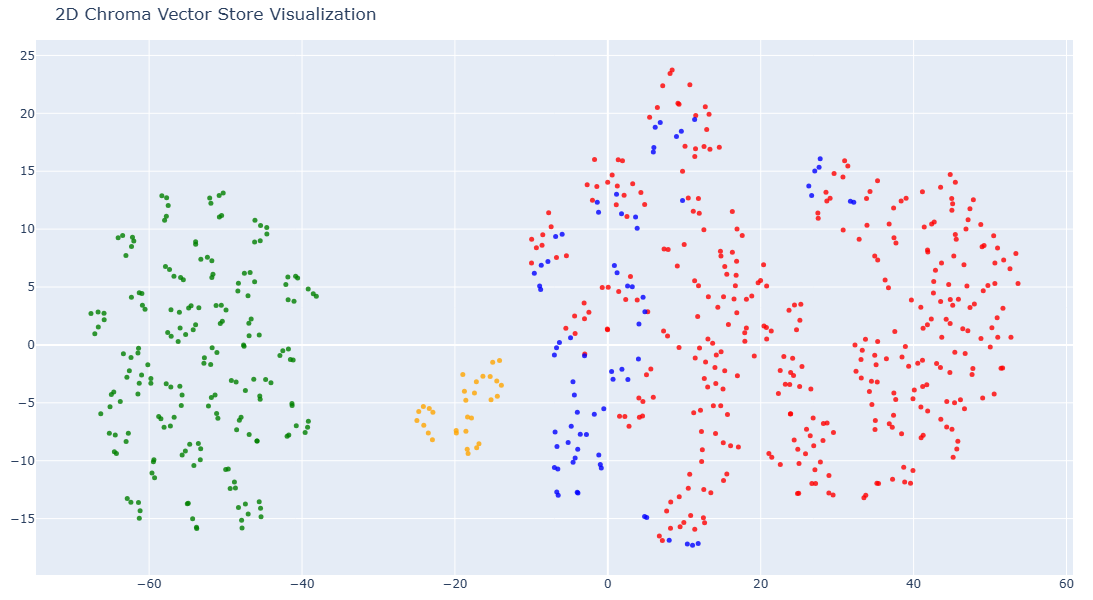

In [16]:
tsne = TSNE(n_components=2, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 2D scatter plot
fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(title='2D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x',yaxis_title='y'),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

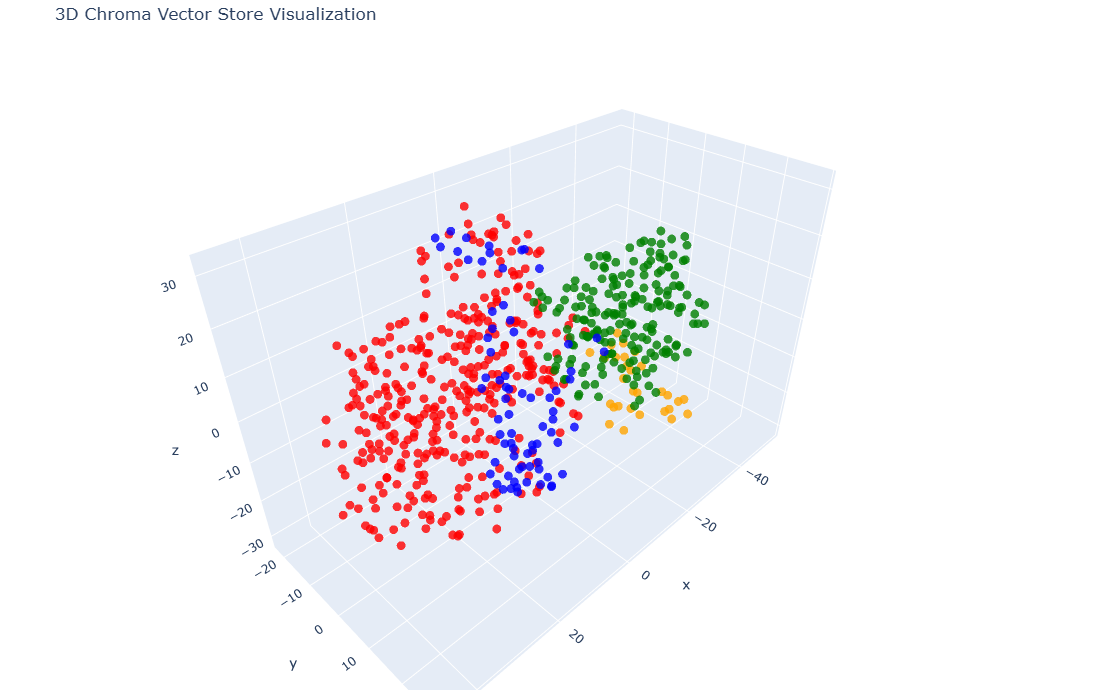

In [17]:
tsne = TSNE(n_components=3, random_state=42)
reduced_vectors = tsne.fit_transform(vectors)

# Create the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    z=reduced_vectors[:, 2],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D Chroma Vector Store Visualization',
    scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'),
    width=900,
    height=700,
    margin=dict(r=10, b=10, l=10, t=40)
)

fig.show()

## Building Advance RAG

Techniques to be used: 
1. Reranking - Reorder the rank results
2. Query Rewriting

In [18]:
class RankOrder(BaseModel):
    order: list[int] = Field(
        description="The order of relevance of chunks, from most relevant to least relevant, by chunk id number"
    )

In [19]:
def rerank(question, chunks):
    system_prompt = """
You are a document re-ranker.
You are provided with a question and a list of relevant chunks of text from a query of a knowledge base.
The chunks are provided in the order they were retrieved; this should be approximately ordered by relevance, but you may be able to improve on that.
You must rank order the provided chunks by relevance to the question, with the most relevant chunk first.
Reply only with the list of ranked chunk ids, nothing else. Include all the chunk ids you are provided with, reranked.
"""
    user_prompt = f"The user has asked the following question:\n\n{question}\n\nOrder all the chunks of text by relevance to the question, from most relevant to least relevant. Include all the chunk ids you are provided with, reranked.\n\n"
    user_prompt += "Here are the chunks:\n\n"
    for index, chunk in enumerate(chunks):
        user_prompt += f"# CHUNK ID: {index + 1}:\n\n{chunk.page_content}\n\n"
    user_prompt += "Reply only with the list of ranked chunk ids, nothing else."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    response = completion(model=MODEL, messages=messages, response_format=RankOrder)
    reply = response.choices[0].message.content
    order = RankOrder.model_validate_json(reply).order
    print(order)
    return [chunks[i - 1] for i in order]

In [42]:
RETRIEVAL_K = 10
client = genai.Client()
'''
same as
retriever = vectorstore.as_retriever()
retriever.invoke("Who is Avery?")
'''
def fetch_context_unranked(question):
    query = client.models.embed_content(
        model=embedding_model,
        contents= [question]
    )
    results = collection.query(query_embeddings=[query.embeddings[0].values], n_results=RETRIEVAL_K)
    chunks = []
    for result in zip(results["documents"][0], results["metadatas"][0]):
        chunks.append(Result(page_content=result[0], metadata=result[1]))
    return chunks

In [26]:
question = "Who won the IIOTY award?"
chunks = fetch_context_unranked(question)

In [27]:
for chunk in chunks:
    print(chunk.page_content[:15]+"...")

Senior Data Eng...
Maxine Thompson...
Maxine Thompson...
Maxine Thompson...
Innovate Initia...
Complete Perfor...
Full Compensati...
Success of New ...
Maxine Thompson...
Analytics & Rep...


In [28]:
reranked = rerank(question, chunks)

[1, 2, 3, 4, 9, 5, 7, 6, 8, 10]


In [29]:
for chunk in reranked:
    print(chunk.page_content[:15]+"...")

Senior Data Eng...
Maxine Thompson...
Maxine Thompson...
Maxine Thompson...
Maxine Thompson...
Innovate Initia...
Full Compensati...
Complete Perfor...
Success of New ...
Analytics & Rep...


In [30]:
question = "Who went to Manchester University?"
RETRIEVAL_K = 20
chunks = fetch_context_unranked(question)
for index, c in enumerate(chunks):
    if "manchester" in c.page_content.lower():
        print(index)

14


In [31]:
reranked = rerank(question, chunks)

[15, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20]


In [32]:
for index, c in enumerate(reranked):
    if "manchester" in c.page_content.lower():
        print(index)

0


In [33]:
reranked[0].page_content

"Jessica Liu's Compensation and Additional Profile Information\n\nJessica Liu's compensation history shows a progression from a $68,000 base salary in 2020 to $92,000 in 2023, accompanied by annual bonuses. She holds a BS in Computer Science, is proficient in React, TypeScript, and HTML/CSS, and is actively learning Next.js and GraphQL. Her work style is remote, she's a strong communicator, and feedback notes her reliability and improving technical decision-making.\n\n## Compensation History\n- **2023:** Base Salary: $92,000 + Bonus: $6,000\n- **2022:** Base Salary: $85,000 + Bonus: $4,000\n- **2021:** Base Salary: $72,000 + Bonus: $2,000\n- **2020:** Base Salary: $68,000\n\n## Other HR Notes\n- **Education:** BS in Computer Science from University of Manchester\n- **Skills:** Proficient in React, TypeScript, HTML/CSS, Jest for testing. Learning Next.js and GraphQL.\n- **Professional Development:** Completed Advanced React Patterns course (2023). Actively contributes to open-source pro

In [34]:
def fetch_context(question):
    chunks = fetch_context_unranked(question)
    return rerank(question, chunks)

In [35]:
SYSTEM_PROMPT = """
You are a knowledgeable, friendly assistant representing the company Insurellm.
You are chatting with a user about Insurellm.
Your answer will be evaluated for accuracy, relevance and completeness, so make sure it only answers the question and fully answers it.
If you don't know the answer, say so.
For context, here are specific extracts from the Knowledge Base that might be directly relevant to the user's question:
{context}

With this context, please answer the user's question. Be accurate, relevant and complete.
"""

In [36]:
# In the context, include the source of the chunk

def make_rag_messages(question, history, chunks):
    context = "\n\n".join(f"Extract from {chunk.metadata['source']}:\n{chunk.page_content}" for chunk in chunks)
    system_prompt = SYSTEM_PROMPT.format(context=context)
    return [{"role": "system", "content": system_prompt}] + history + [{"role": "user", "content": question}]

In [37]:
def rewrite_query(question, history=[]):
    """Rewrite the user's question to be a more specific question that is more likely to surface relevant content in the Knowledge Base."""
    message = f"""
You are in a conversation with a user, answering questions about the company Insurellm.
You are about to look up information in a Knowledge Base to answer the user's question.

This is the history of your conversation so far with the user:
{history}

And this is the user's current question:
{question}

Respond only with a single, refined question that you will use to search the Knowledge Base.
It should be a VERY short specific question most likely to surface content. Focus on the question details.
Don't mention the company name unless it's a general question about the company.
IMPORTANT: Respond ONLY with the knowledgebase query, nothing else.
"""
    response = completion(model=MODEL, messages=[{"role": "system", "content": message}])
    return response.choices[0].message.content

In [38]:
rewrite_query("Who won the IIOTY award?", [])

'IIOTY award winner'

In [39]:
def answer_question(question: str, history: list[dict] = []) -> tuple[str, list]:
    """
    Answer a question using RAG and return the answer and the retrieved context
    """
    query = rewrite_query(question, history)
    print(query)
    chunks = fetch_context(query)
    messages = make_rag_messages(question, history, chunks)
    response = completion(model=MODEL, messages=messages)
    return response.choices[0].message.content, chunks

In [40]:
answer_question("Who won the IIOTY award?", [])

IIOTY award winner
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


('Maxine Thompson won the prestigious Insurellm IIOTY Innovator Award in 2023.',
 [Result(page_content="Senior Data Engineer and Innovator Award\n\nThis chunk covers Maxine Thompson's career from Data Engineer to Senior Data Engineer. It notes her technical excellence despite earlier communication issues, her promotion in January 2021 due to successfully leading a project that improved data retrieval times, her current role in mentoring junior engineers and strategic data initiatives, and her recognition as Insurellm Innovator of the Year in 2023.\n\ntechnical skills, communication issues with non-technical teams led to some project delays.  - **January 2021 - Present**: **Senior Data Engineer**  * Maxine was promoted to Senior Data Engineer after successfully leading a pivotal project that improved data retrieval times by 30%. She now mentors junior engineers and is involved in strategic data initiatives, solidifying her position as a valued asset at Insurellm. She was recognized as I

In [41]:
answer_question("Who went to Manchester University?", [])

People who went to Manchester University
[8, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


('Jessica Liu received her BS in Computer Science from the University of Manchester.',
 [Result(page_content="Jessica Liu's Compensation and Additional Profile Information\n\nJessica Liu's compensation history shows a progression from a $68,000 base salary in 2020 to $92,000 in 2023, accompanied by annual bonuses. She holds a BS in Computer Science, is proficient in React, TypeScript, and HTML/CSS, and is actively learning Next.js and GraphQL. Her work style is remote, she's a strong communicator, and feedback notes her reliability and improving technical decision-making.\n\n## Compensation History\n- **2023:** Base Salary: $92,000 + Bonus: $6,000\n- **2022:** Base Salary: $85,000 + Bonus: $4,000\n- **2021:** Base Salary: $72,000 + Bonus: $2,000\n- **2020:** Base Salary: $68,000\n\n## Other HR Notes\n- **Education:** BS in Computer Science from University of Manchester\n- **Skills:** Proficient in React, TypeScript, HTML/CSS, Jest for testing. Learning Next.js and GraphQL.\n- **Profess

In [43]:
answer_question("tell me about carllm",[])

CarLLM
[1, 2, 4, 8, 9, 10, 5, 6, 3, 7]


("Carllm is Insurellm's AI-powered auto insurance product, developed to modernize how insurance companies provide coverage. It utilizes cutting-edge artificial intelligence and advanced algorithms to offer personalized auto insurance solutions, ensuring optimal coverage while minimizing costs for customers. Carllm supports both B2B and B2C customers, designed to streamline operations and enhance customer satisfaction and retention for insurance providers.\n\nKey features of Carllm include:\n*   **AI-Powered Risk Assessment**: Leverages AI to analyze driver behavior, vehicle conditions, and historical claims data, enabling insurers to make informed decisions and set competitive premiums.\n*   **Instant Quoting**: Its AI engine processes data in real-time, drastically reducing the time it takes to generate near-instant insurance quotes for customers.\n*   **Customizable Coverage Plans**: Offers flexibility in tailoring insurance options.\n*   **Fraud Detection Systems**: Employs advanced